# Machine-learning forecasts: XGBoost Random Forest and LightGBM

This notebook mirrors the dataset splits, recursive forecast horizon, forecast plots, result tables, metrics, and exports in `classical_models.ipynb`. It evaluates XGBoost Random Forest and LightGBM on both the original target and a training-only `AutoStationaryTransformer` target.

Tree regressors are not time-series models by themselves, so target lags remain necessary. Exogenous weather/economic variables and linear-model-only preprocessing are omitted. Forecasts are recursive: validation/test observations are never used to construct their own lag features.

## Validation and final test protocol

The Chapter 8 `01`/`02` notebooks differ by target representation (original/transformed); their `a` counterparts repeat the chosen workflow on the held-out test set. Here `EVALUATION_SPLIT='validation'` fits on train and evaluates on validation. After every modeling choice is frozen, switch it to `'test'`; the notebook then refits on train+validation and evaluates once on test.

Each reported metric summarizes the complete selected horizon for one series/model: MAE and MSE average the period errors, RMSE is the square root of the full-horizon MSE, and forecast bias compares horizon totals. For tuning, use expanding-window rolling-origin folds. `TimeSeriesSplit` is suitable when its folds preserve time order, feature construction is fold-local, and `test_size` matches the intended horizon; recursive models must forecast every fold without using validation observations as lags. For panel data, keep fold boundaries aligned in calendar time across series rather than splitting arbitrary rows.
All tables always describe the split named by `EVALUATION_SPLIT`. Therefore, they correctly show validation errors during the selection run; the test set is not evaluated automatically in the same execution. After changing the setting to `'test'` and rerunning from the top, the notebook loads the saved per-series validation selections, refits only the required winning models on train+validation, and reports those locked forecasts on test. No test-set candidate grid is produced and test errors never select a new winner.


In [1]:
import os
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from lightgbm import LGBMRegressor
from xgboost import XGBRFRegressor

from thesis.blending import (
    BLEND_MODEL_NAME,
    apply_frozen_ridge_blenders,
    blend_model_name,
    fit_validation_ridge_blenders,
)
from thesis.data_preparation import (
    MANUAL_DATASETS, POINT_FORECAST_DATASETS,
    create_train_val_test_splits,
    load_dataset,
)
from thesis.evaluation import (
    build_results_table,
    export_comparison_metrics,
    export_results_table_latex,
    export_results_tables_latex,
    plot_forecast_matplotlib,
    prepare_comparison_metrics,
    style_results_table,
)
from thesis.ml_evaluation import (
    evaluate_recursive_ml_models,
    tune_recursive_ml_models,
)
from thesis.model_selection import (
    candidate_registry,
    export_model_selection,
    load_model_selection,
    export_tuning_results,
    load_tuning_results,
    merge_model_selections,
    summarize_model_selection,
)
from thesis.reporting import (
    apply_matplotlib_dataset_labels,
    display_series_name,
    figure_path,
    humanize_results_table,
    metadata_for,
    publication_latex,
    save_matplotlib_figure,
)
from thesis.runtime import CPU_THREADS
from src.transforms.target_transformations import AutoStationaryTransformer

%load_ext autoreload
%autoreload 2


In [12]:
SEED = 67
# Batch mode loops over all manual datasets; it does not create a global model.
EXECUTION_MODE = 'batch'  # 'single' or 'batch'
ACTIVE_DATASET = 'emae'  # used only in single mode
EVALUATION_SPLIT = 'test'  # run validation after candidate changes, then test
RUN_HYPERPARAMETER_TUNING = EVALUATION_SPLIT == 'validation'
REUSE_SAVED_TUNING = True
OPTUNA_N_TRIALS = 25
OPTUNA_N_SPLITS = 3
LIGHTGBM_EARLY_STOPPING_ROUNDS = 100
LIGHTGBM_EARLY_STOPPING_FRACTION = 0.2
TUNING_RESULTS_PATH = Path('thesis/model_configs/ml_optuna_tuning.json')
RIDGE_BLEND_ALPHA = 1.0
PREDICTIONS_DIR = Path('thesis/predictions')
ML_CANDIDATES_PATH = Path('thesis/model_configs/ml_validation_candidates.json')
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

assert EXECUTION_MODE in {'single', 'batch'}
assert EVALUATION_SPLIT in {'validation', 'test'}
np.random.seed(SEED)
if EXECUTION_MODE == 'single':
    datasets_to_process = [ACTIVE_DATASET]
else:
    datasets_to_process = list(POINT_FORECAST_DATASETS)
ML_SELECTION_PATH = Path('thesis/model_configs/ml_validation_selection.json')
CLASSICAL_SELECTION_PATH = Path('thesis/model_configs/classical_validation_selection.json')
RIDGE_BLEND_CONFIG_PATH = Path('thesis/model_configs/ridge_blend_validation.json')
os.makedirs('thesis/metrics', exist_ok=True)
os.makedirs('thesis/results', exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
ml_configs_by_dataset = {}
saved_tuning_results = (
    load_tuning_results(TUNING_RESULTS_PATH)
    if REUSE_SAVED_TUNING and TUNING_RESULTS_PATH.exists()
    else {}
)
all_tuning_results = dict(saved_tuning_results)
print(f'Datasets: {datasets_to_process} | Evaluation: {EVALUATION_SPLIT}')
if EXECUTION_MODE != 'single':
    print('ACTIVE_DATASET is ignored outside single mode.')

Datasets: ['emae', 'ecai_us', 'real_gdp_argentina', 'real_gdp_us'] | Evaluation: test
ACTIVE_DATASET is ignored outside single mode.


## Model, lag, and Bayesian hyperparameter configuration

Lag sets are dataset configuration, not a fixed yearly/monthly assumption. Set `ml_lags` in `thesis/data_preparation.py`, or use `ML_LAGS_BY_DATASET` below for an experiment-specific override. These are past target values—not exogenous inputs. No scaler is needed for tree models.

The Bayesian search follows the Chapter 10 Optuna/TPE example, but scores every trial with calendar-aligned expanding-window recursive forecasts. Every estimator and every TPE sampler uses the common `SEED=67`; model order does not alter the sampler seed. Raw and AutoStationary targets are tuned independently. Validation runs save best parameters and tuning durations; a later validation run reuses a candidate only when its seed, trial count, fold count, horizon, metric, and early-stopping protocol still match. Test runs reuse all selected parameters without rerunning Optuna. Validation `Time Elapsed` includes the stored tuning cost plus final fit/forecast time, whereas test `Time Elapsed` contains only the frozen model's train+validation refit and forecast.

The two algorithms require different regimes. `XGBRFRegressor` is a standalone random forest: its learning rate remains fixed at 1 and Optuna tunes forest size, tree complexity, row/column sampling, and regularization. LightGBM is gradient boosted and tunes shrinkage, structural complexity, subsampling, and regularization under the same outer rolling-origin score. Its effective boosting iteration is selected from the final 20% of each fold's fitting rows. That internal early-stopping segment is never the outer validation horizon; after selecting the iteration, the estimator is refitted on every fold-fitting row.

In [13]:
def make_xgb_random_forest(params=None):
    model_params = {
        'n_estimators': 300, 'max_depth': 5, 'min_child_weight': 1.0,
        'subsample': 0.8, 'colsample_bynode': 0.8,
        'reg_alpha': 0.0, 'reg_lambda': 1.0, 'gamma': 0.0,
        'learning_rate': 1.0,
        'objective': 'reg:squarederror', 'tree_method': 'hist',
        'random_state': SEED, 'n_jobs': CPU_THREADS, 'verbosity': 0,
    }
    model_params.update(params or {})
    return XGBRFRegressor(**model_params)


def suggest_xgb_random_forest(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.5, 20.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }


def make_lightgbm(params=None):
    model_params = {
        'n_estimators': 6000, 'learning_rate': 0.03, 'num_leaves': 31,
        'min_child_samples': 20, 'subsample': 0.8, 'subsample_freq': 1,
        'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 0.0,
        'random_state': SEED, 'n_jobs': CPU_THREADS, 'verbosity': -1,
    }
    model_params.update(params or {})
    return LGBMRegressor(**model_params)


def suggest_lightgbm(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 96),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }


ML_ESTIMATOR_FACTORIES = {
    'XGBRandomForest': make_xgb_random_forest,
    'LightGBM': make_lightgbm,
}
ML_PARAMETER_SUGGESTERS = {
    'XGBRandomForest': suggest_xgb_random_forest,
    'LightGBM': suggest_lightgbm,
}
ML_ESTIMATOR_PROTOCOLS = {
    'XGBRandomForest': {
        'backend': 'CPU', 'cpu_threads': CPU_THREADS,
        'search_space': 'xgbrandomforest_cpu_v1',
    },
    'LightGBM': {
        'backend': 'CPU', 'cpu_threads': CPU_THREADS,
        'search_space': 'lightgbm_cpu_v1',
    },
}
EARLY_STOPPING_ROUNDS_BY_MODEL = {
    'LightGBM': LIGHTGBM_EARLY_STOPPING_ROUNDS,
}
def estimator_from_tuning_record(model_name, record):
    params = dict(record['best_params'])
    selected_iteration = record.get('selected_boosting_iteration')
    if model_name == 'LightGBM' and selected_iteration is not None:
        params['n_estimators'] = int(selected_iteration)
    return ML_ESTIMATOR_FACTORIES[model_name](params)


ML_MODELS = {name: factory() for name, factory in ML_ESTIMATOR_FACTORIES.items()}
ML_MODELS_BY_DATASET = {}  # optional: {'emae': {'candidate_name': estimator}}
ML_LAGS_BY_DATASET = {}  # optional experiment override: {'emae': [1, 2, 12, 24]}
ML_MODELS

{'XGBRandomForest': XGBRFRegressor(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=0.0, grow_policy=None, importance_type=None,
                interaction_constraints=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=5, max_leaves=None,
                min_child_weight=1.0, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=300, n_jobs=4,
                num_parallel_tree=None, objective='reg:squarederror',
                random_state=67, ...),
 'LightGBM': LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=6000,
               n_jobs=4, random_state=67, subsample=0.8, subsample_freq=1,
               verbosit

In [14]:
all_results = {}
frozen_selection = None
if EVALUATION_SPLIT == 'test':
    selection_file = ML_SELECTION_PATH
    if not selection_file.exists():
        raise FileNotFoundError(
            f'No frozen validation selection found at {selection_file}; run validation first.'
        )
    frozen_selection = load_model_selection(selection_file)

for dataset_name in datasets_to_process:
    dataset_type = 'manual'
    df, config = load_dataset(dataset_name, dataset_type)
    ts_train, ts_val, ts_test, id_col, time_col, target_col = (
        create_train_val_test_splits(df, config, dataset_type)
    )
    if EVALUATION_SPLIT == 'validation':
        fit_df, eval_df = ts_train, ts_val
    else:
        fit_df = pd.concat([ts_train, ts_val], ignore_index=True)
        eval_df = ts_test

    seasonality = int(config.get('seasonality', 1))
    stationary_transformer_factory = partial(
        AutoStationaryTransformer,
        **({'seasonal_period': seasonality} if seasonality > 1 else {}),
    )
    default_lags = config.get(
        'ml_lags', list(range(1, seasonality + 1)) + [2 * seasonality]
    )
    lags = list(ML_LAGS_BY_DATASET.get(dataset_name, default_lags))
    if not lags or any(int(lag) != lag or lag < 1 for lag in lags):
        raise ValueError(f'{dataset_name}: ml_lags must contain positive integers')
    lags = sorted(set(map(int, lags)))
    horizon_sizes = eval_df.groupby(id_col).size()
    if horizon_sizes.nunique() != 1:
        raise ValueError('Every series must have the same evaluation horizon')
    evaluation_horizon = int(horizon_sizes.iloc[0])
    tuning_horizon = int(config.get('tuning_horizon', evaluation_horizon))
    if EVALUATION_SPLIT == 'test':
        for target_winners in frozen_selection['per_series'][dataset_name].values():
            for winner in target_winners.values():
                forecasting = winner['config']['forecasting']
                if (
                    forecasting.get('freq') != config['freq']
                    or forecasting.get('lags') != lags
                ):
                    raise ValueError(
                        f'{dataset_name}: lag/frequency configuration changed after validation; '
                        'restore it or re-run validation tuning'
                    )

    transformer_factories = {
        'Original': None,
        'AutoStationary': stationary_transformer_factory,
    }
    custom_models = ML_MODELS_BY_DATASET.get(dataset_name)
    models_by_target = {}
    tuning_times_by_target = {}
    dataset_tuning = {}

    if custom_models is not None and EVALUATION_SPLIT == 'validation':
        for target_version in transformer_factories:
            models_by_target[target_version] = custom_models
            tuning_times_by_target[target_version] = {name: 0.0 for name in custom_models}
    elif EVALUATION_SPLIT == 'validation' and RUN_HYPERPARAMETER_TUNING:
        for target_version, transformer_factory in transformer_factories.items():
            n_splits = int(config.get('optuna_n_splits', OPTUNA_N_SPLITS))
            n_trials = int(config.get('optuna_n_trials', OPTUNA_N_TRIALS))
            selection_metric = config.get('selection_metric', 'rmse')
            stopping_fraction = float(
                config.get('early_stopping_fraction', LIGHTGBM_EARLY_STOPPING_FRACTION)
            )
            saved_target = (
                saved_tuning_results.get(dataset_name, {}).get(target_version, {})
                if REUSE_SAVED_TUNING else {}
            )
            reusable = {
                name: record for name, record in saved_target.items()
                if name in ML_ESTIMATOR_FACTORIES
                and record.get('sampler_seed') == SEED
                and record.get('n_trials') == n_trials
                and record.get('n_splits') == n_splits
                and record.get('horizon') == tuning_horizon
                and record.get('selection_metric') == selection_metric
                and record.get('early_stopping_fraction') == stopping_fraction
                and record.get('estimator_protocol') == ML_ESTIMATOR_PROTOCOLS[name]
                and record.get('early_stopping_rounds')
                    == EARLY_STOPPING_ROUNDS_BY_MODEL.get(name)
                and (
                    target_version != 'AutoStationary'
                    or name != 'LightGBM'
                    or (
                        record.get('early_stopping_protocol')
                        == 'raw_inner_fit_then_frozen_outer_refit'
                        and record.get('selected_boosting_iteration') is not None
                    )
                )
            }
            missing_names = [
                name for name in ML_ESTIMATOR_FACTORIES if name not in reusable
            ]
            tuned_models = {
                name: estimator_from_tuning_record(name, record)
                for name, record in reusable.items()
            }
            tuning_times = {
                name: float(record.get('tuning_seconds', 0.0))
                for name, record in reusable.items()
            }
            tuning_summary = dict(reusable)
            if reusable:
                print(
                    f'{dataset_name} / {target_version}: reusing compatible '
                    f'Optuna results for {sorted(reusable)}'
                )
            if missing_names:
                new_models, new_times, new_summary = tune_recursive_ml_models(
                    fit_df,
                    {name: ML_ESTIMATOR_FACTORIES[name] for name in missing_names},
                    {name: ML_PARAMETER_SUGGESTERS[name] for name in missing_names},
                    lags, horizon=tuning_horizon, n_splits=n_splits,
                    n_trials=n_trials, metric=selection_metric, seed=SEED,
                    id_col=id_col, time_col=time_col, target_col=target_col,
                    freq=config['freq'],
                    target_transformer_factory=transformer_factory,
                    target_transformation=target_version,
                    early_stopping_rounds_by_model=EARLY_STOPPING_ROUNDS_BY_MODEL,
                    early_stopping_fraction=stopping_fraction,
                    estimator_protocols=ML_ESTIMATOR_PROTOCOLS,
                )
                tuned_models.update(new_models)
                tuning_times.update(new_times)
                tuning_summary.update(new_summary)
            models_by_target[target_version] = tuned_models
            tuning_times_by_target[target_version] = tuning_times
            dataset_tuning[target_version] = tuning_summary
        all_tuning_results[dataset_name] = dataset_tuning
    elif dataset_name in saved_tuning_results:
        dataset_tuning = saved_tuning_results[dataset_name]
        for target_version in transformer_factories:
            target_tuning = dataset_tuning[target_version]
            required_models = set(ML_ESTIMATOR_FACTORIES)
            incompatible_protocol = {
                model_name: {
                    'seed': record.get('sampler_seed'),
                    'estimator_protocol': record.get('estimator_protocol'),
                }
                for model_name, record in target_tuning.items()
                if record.get('sampler_seed') != SEED
                or record.get('estimator_protocol') != ML_ESTIMATOR_PROTOCOLS.get(model_name)
            }
            if incompatible_protocol:
                raise ValueError(
                    f'{dataset_name} / {target_version}: saved tuning uses an incompatible '
                    f'seed or compute/search protocol: {incompatible_protocol}. '
                    'Re-run validation tuning before test evaluation.'
                )
            if target_version == 'AutoStationary':
                lightgbm_record = target_tuning.get('LightGBM', {})
                if (
                    lightgbm_record.get('early_stopping_protocol')
                    != 'raw_inner_fit_then_frozen_outer_refit'
                    or lightgbm_record.get('selected_boosting_iteration') is None
                ):
                    raise ValueError(
                        f'{dataset_name}: transformed LightGBM tuning predates the '
                        'corrected nested early-stopping procedure; rerun validation tuning'
                    )
            models_by_target[target_version] = {
                name: estimator_from_tuning_record(name, record)
                for name, record in target_tuning.items()
                if name in required_models
            }
            missing_models = required_models - set(models_by_target[target_version])
            if missing_models:
                raise ValueError(
                    f'{dataset_name} / {target_version}: no frozen Optuna parameters for '
                    f'{sorted(missing_models)}; re-run validation tuning'
                )
            tuning_times_by_target[target_version] = {
                name: 0.0 for name in models_by_target[target_version]
            }
    else:
        if EVALUATION_SPLIT == 'test' and REUSE_SAVED_TUNING:
            raise FileNotFoundError(
                f'No frozen Optuna parameters for {dataset_name}; run validation tuning first'
            )
        for target_version in transformer_factories:
            models_by_target[target_version] = ML_MODELS
            tuning_times_by_target[target_version] = {name: 0.0 for name in ML_MODELS}

    ml_configs_by_dataset[dataset_name] = {}
    for target_version, target_models in models_by_target.items():
        ml_configs_by_dataset[dataset_name][target_version] = candidate_registry(target_models)
        for model_name, config_record in ml_configs_by_dataset[dataset_name][target_version].items():
            config_record['forecasting'] = {
                'freq': config['freq'], 'seasonality': seasonality,
                'lags': lags, 'strategy': 'recursive',
            }
            config_record['tuning'] = dataset_tuning.get(target_version, {}).get(model_name)
    print(f'\n{dataset_name}: {len(fit_df)} fit rows -> {len(eval_df)} {EVALUATION_SPLIT} rows; lags={lags}')

    stationary_fixed_iterations = {
        model_name: int(record['selected_boosting_iteration'])
        for model_name, record in dataset_tuning.get('AutoStationary', {}).items()
        if record.get('selected_boosting_iteration') is not None
    }

    original = evaluate_recursive_ml_models(
        fit_df, eval_df, models_by_target['Original'], lags, id_col, time_col, target_col,
        freq=config['freq'], target_transformation='Original',
        tuning_time_by_model=tuning_times_by_target['Original'],
        early_stopping_rounds_by_model=EARLY_STOPPING_ROUNDS_BY_MODEL,
        early_stopping_fraction=float(
            config.get('early_stopping_fraction', LIGHTGBM_EARLY_STOPPING_FRACTION)
        ),
        early_stopping_metric=config.get('selection_metric', 'rmse'),
    )
    stationary = evaluate_recursive_ml_models(
        fit_df, eval_df, models_by_target['AutoStationary'], lags, id_col, time_col, target_col,
        freq=config['freq'],
        target_transformer_factory=stationary_transformer_factory,
        target_transformation='AutoStationary',
        model_suffix='_AutoStationary',
        tuning_time_by_model=tuning_times_by_target['AutoStationary'],
        early_stopping_rounds_by_model=EARLY_STOPPING_ROUNDS_BY_MODEL,
        early_stopping_fraction=float(
            config.get('early_stopping_fraction', LIGHTGBM_EARLY_STOPPING_FRACTION)
        ),
        early_stopping_metric=config.get('selection_metric', 'rmse'),
        fixed_iterations_by_model=stationary_fixed_iterations,
    )

    stationary_predictions = stationary[0].drop(columns=[target_col])
    predictions = original[0].merge(
        stationary_predictions, on=[id_col, time_col], how='left'
    )
    metrics = pd.concat([original[1], stationary[1]], ignore_index=True)
    feature_importance = pd.concat([original[3], stationary[3]], ignore_index=True)
    all_results[dataset_name] = {
        'config': config, 'type': dataset_type, 'id_col': id_col,
        'time_col': time_col, 'target_col': target_col, 'lags': lags,
        'fit_df': fit_df, 'eval_df': eval_df,
        'results': predictions, 'metrics': metrics,
        'feature_importance': feature_importance,
        'fitted_models': {'Original': original[2], 'AutoStationary': stationary[2]},
        'tuning': dataset_tuning,
    }

if EVALUATION_SPLIT == 'validation' and RUN_HYPERPARAMETER_TUNING:
    tuning_path = export_tuning_results(all_tuning_results, TUNING_RESULTS_PATH)
    print(f'Optuna parameters and timings saved to {tuning_path}')

# The two Ridge layers are meta-trained on external validation forecasts only.
# Consequently they receive no validation performance score: test is their first
# unbiased evaluation. Run the matching classical split before this cell.
classical_selection_path = CLASSICAL_SELECTION_PATH
if not classical_selection_path.exists():
    raise FileNotFoundError(
        f'Run classical validation and its export cell first: {classical_selection_path}'
    )
classical_selection = load_model_selection(classical_selection_path)
missing_classical_datasets = sorted(
    set(all_results) - set(classical_selection.get('per_series', {}))
)
if missing_classical_datasets:
    raise ValueError(
        'The classical validation selection is incomplete for this ML batch: '
        f'{missing_classical_datasets}. Run classical_models validation in '
        'batch mode and its selection/export cells before this blending step.'
    )

if EVALUATION_SPLIT == 'validation':
    ridge_blend_summary = (
        load_model_selection(RIDGE_BLEND_CONFIG_PATH)
        if RIDGE_BLEND_CONFIG_PATH.exists() else {
        'model': BLEND_MODEL_NAME,
        'protocol': (
            'Separate per-series Original and AutoStationary Ridge weights '
            'fitted on external validation forecasts'
        ),
        'alpha': RIDGE_BLEND_ALPHA,
            'per_dataset': {},
        }
    )
    ridge_blend_summary.setdefault('per_dataset', {})
else:
    if not RIDGE_BLEND_CONFIG_PATH.exists():
        raise FileNotFoundError(
            f'No validation-trained Ridge blend found at {RIDGE_BLEND_CONFIG_PATH}; '
            'run ML validation first.'
        )
    ridge_blend_summary = load_model_selection(RIDGE_BLEND_CONFIG_PATH)

for dataset_name, data in all_results.items():
    classical_prediction_path = PREDICTIONS_DIR / (
        f'classical_{EVALUATION_SPLIT}_predictions_{dataset_name}.csv'
    )
    if not classical_prediction_path.exists():
        raise FileNotFoundError(
            f'Run the matching classical export first: {classical_prediction_path}'
        )
    classical_predictions = pd.read_csv(classical_prediction_path)

    if EVALUATION_SPLIT == 'validation':
        blend_config = fit_validation_ridge_blenders(
            classical_predictions=classical_predictions,
            ml_predictions=data['results'],
            classical_selection=classical_selection,
            ml_metrics=data['metrics'],
            dataset_name=dataset_name,
            id_col=data['id_col'],
            time_col=data['time_col'],
            target_col=data['target_col'],
            selection_metric=data['config'].get('selection_metric', 'rmse'),
            alpha=float(data['config'].get('ridge_blend_alpha', RIDGE_BLEND_ALPHA)),
            aggregate_replicates=False,
        )
        ridge_blend_summary['per_dataset'][dataset_name] = blend_config
        export_model_selection(ridge_blend_summary, RIDGE_BLEND_CONFIG_PATH)
        print(
            f'{dataset_name}: Original and AutoStationary Ridge weights fitted on validation; '
            'no in-sample ensemble score is reported.'
        )
    else:
        if dataset_name not in ridge_blend_summary.get('per_dataset', {}):
            raise ValueError(
                f'No frozen Ridge blend configuration for {dataset_name}'
            )
        blended_results, blended_metrics = apply_frozen_ridge_blenders(
            classical_predictions=classical_predictions,
            ml_predictions=data['results'],
            blend_config=ridge_blend_summary['per_dataset'][dataset_name],
            dataset_name=dataset_name,
            id_col=data['id_col'],
            time_col=data['time_col'],
            target_col=data['target_col'],
        )
        data['results'] = blended_results
        data['metrics'] = pd.concat(
            [data['metrics'], blended_metrics], ignore_index=True
        )

    ml_prediction_path = PREDICTIONS_DIR / (
        f'ml_{EVALUATION_SPLIT}_predictions_{dataset_name}.csv'
    )
    data['results'].to_csv(ml_prediction_path, index=False)
    print(f'Forecast CSV saved to {ml_prediction_path}')

if EVALUATION_SPLIT == 'validation':
    print(
        'Validation-trained Ridge coefficients were checkpointed after '
        f'each dataset at {RIDGE_BLEND_CONFIG_PATH}'
    )
print(f'\nCompleted {len(all_results)} dataset(s).')


emae: 252 fit rows -> 12 test rows; lags=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24]

ecai_us: 552 fit rows -> 12 test rows; lags=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24]

real_gdp_argentina: 84 fit rows -> 4 test rows; lags=[1, 2, 3, 4, 8]

real_gdp_us: 92 fit rows -> 4 test rows; lags=[1, 2, 3, 4, 8]
Forecast CSV saved to thesis\predictions\ml_test_predictions_emae.csv
Forecast CSV saved to thesis\predictions\ml_test_predictions_ecai_us.csv
Forecast CSV saved to thesis\predictions\ml_test_predictions_real_gdp_argentina.csv
Forecast CSV saved to thesis\predictions\ml_test_predictions_real_gdp_us.csv

Completed 4 dataset(s).


## Results and forecast plots


PLOTTING: emae (manual)



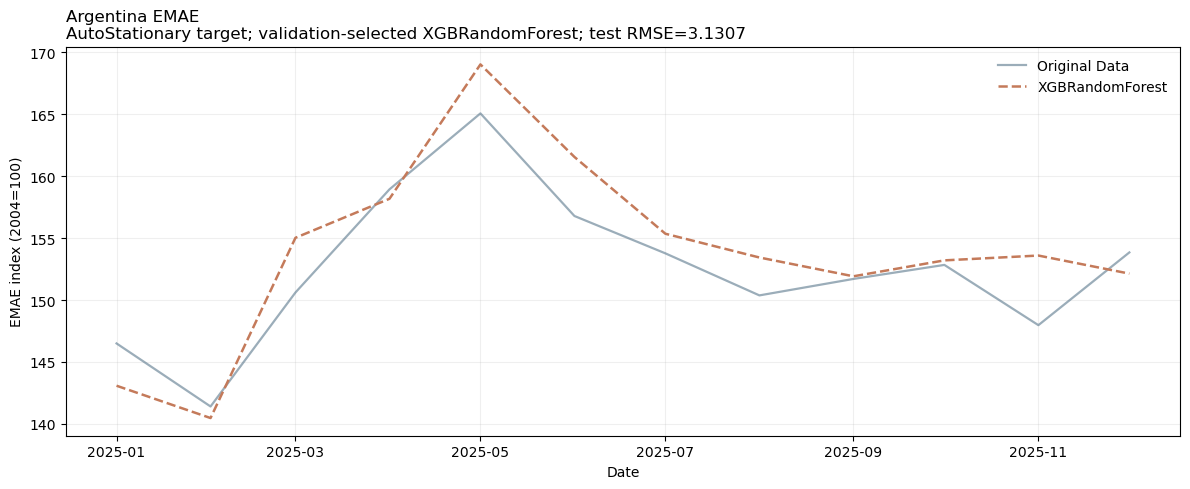

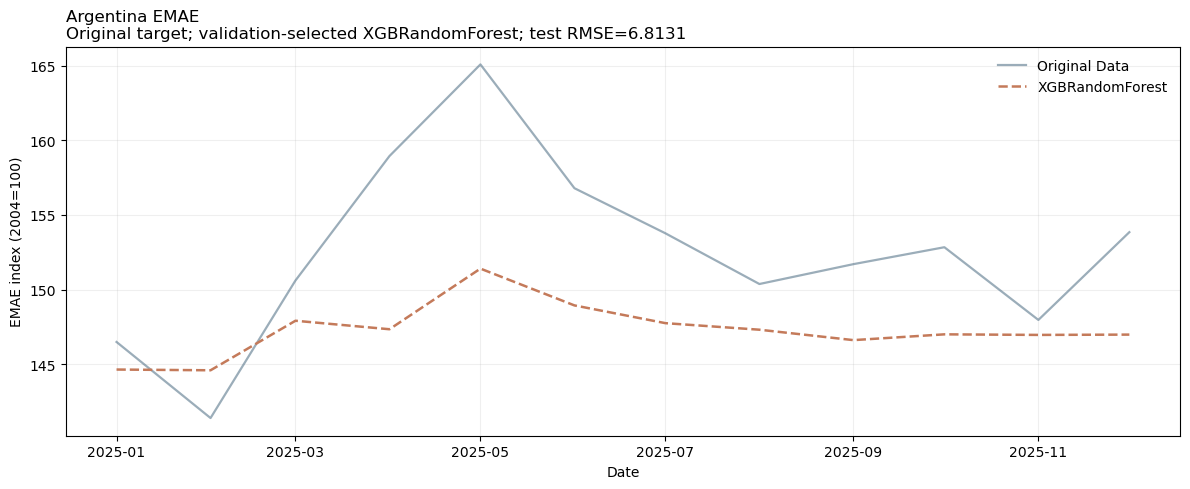

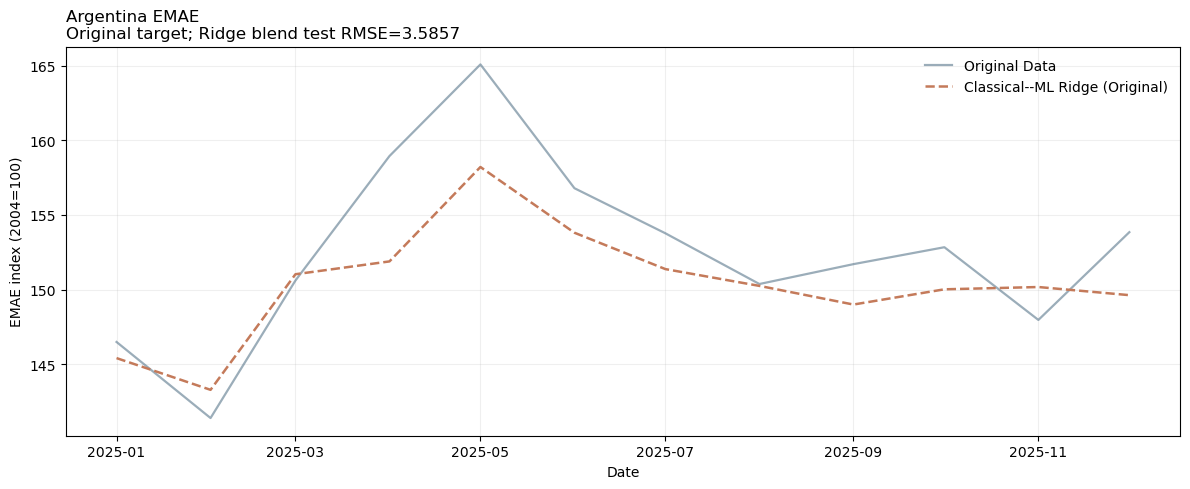

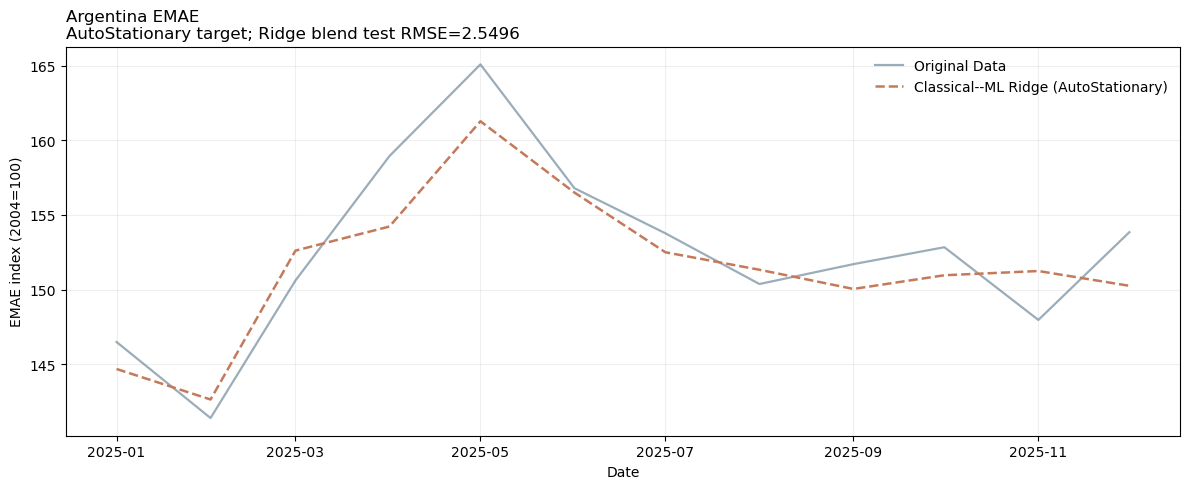


PLOTTING: ecai_us (manual)



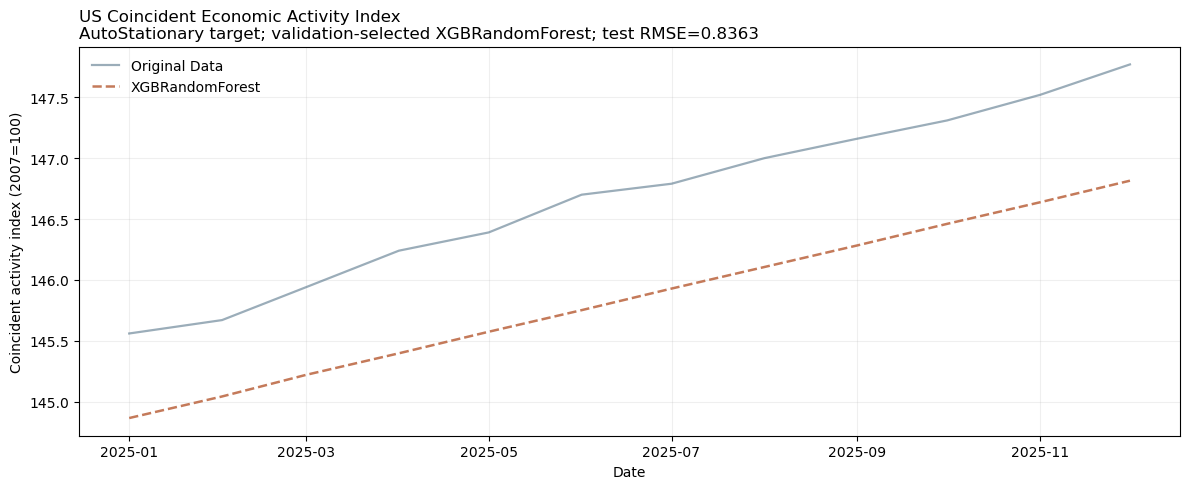

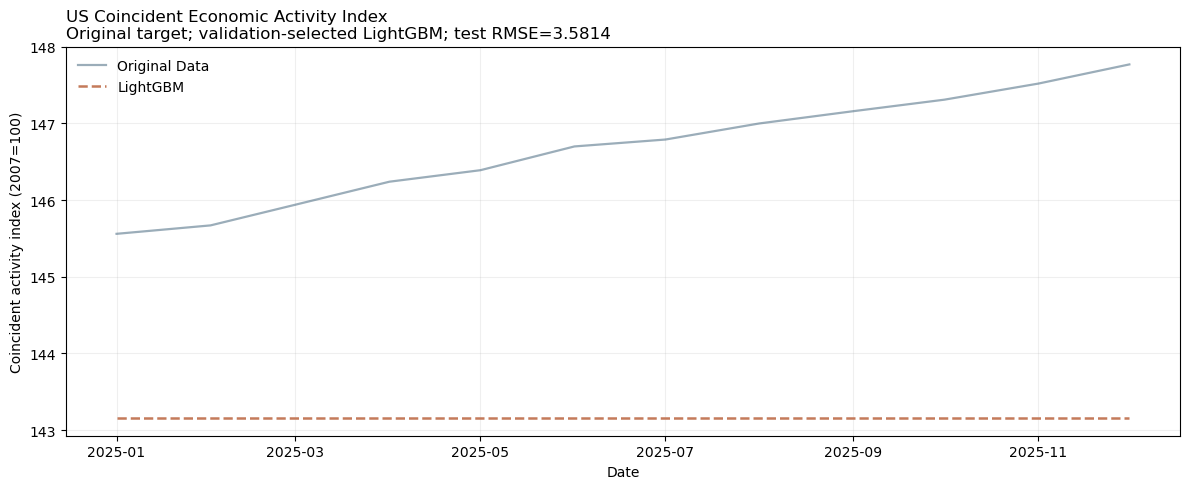

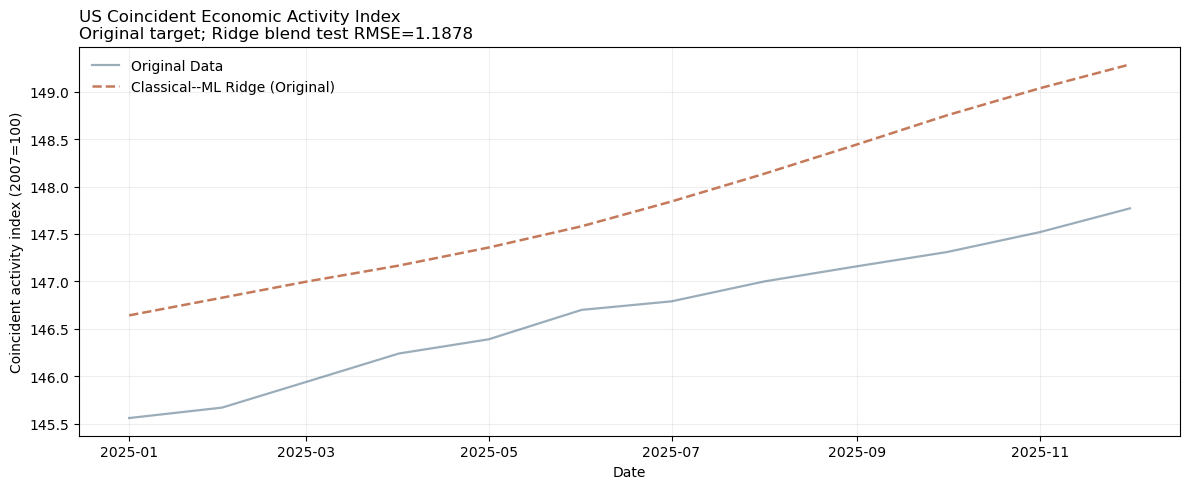

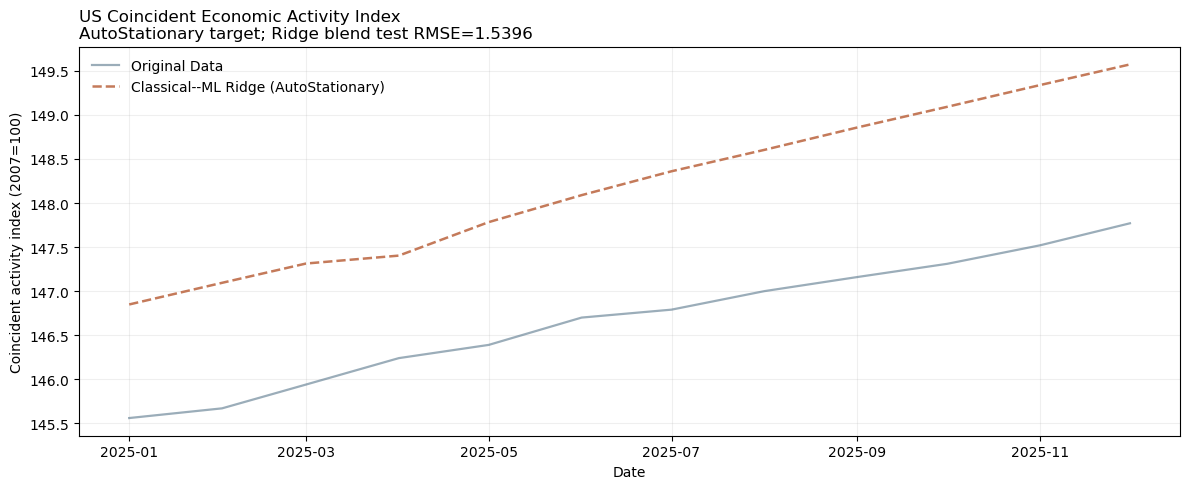


PLOTTING: real_gdp_argentina (manual)



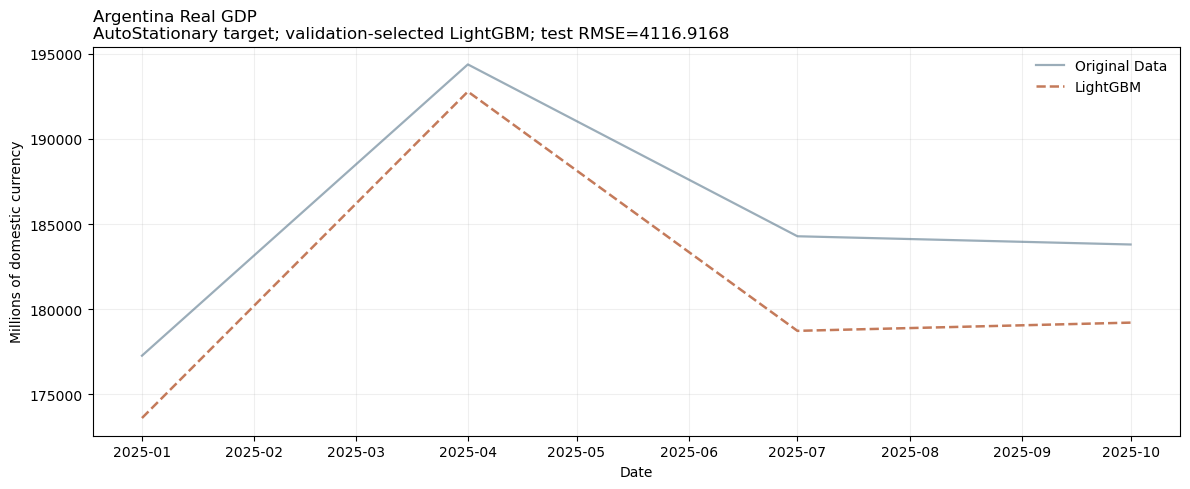

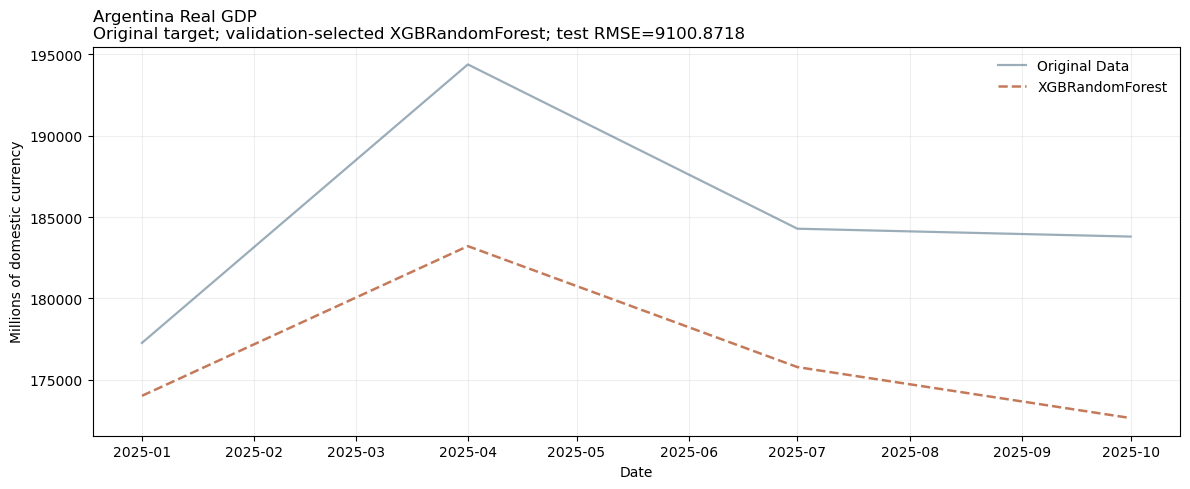

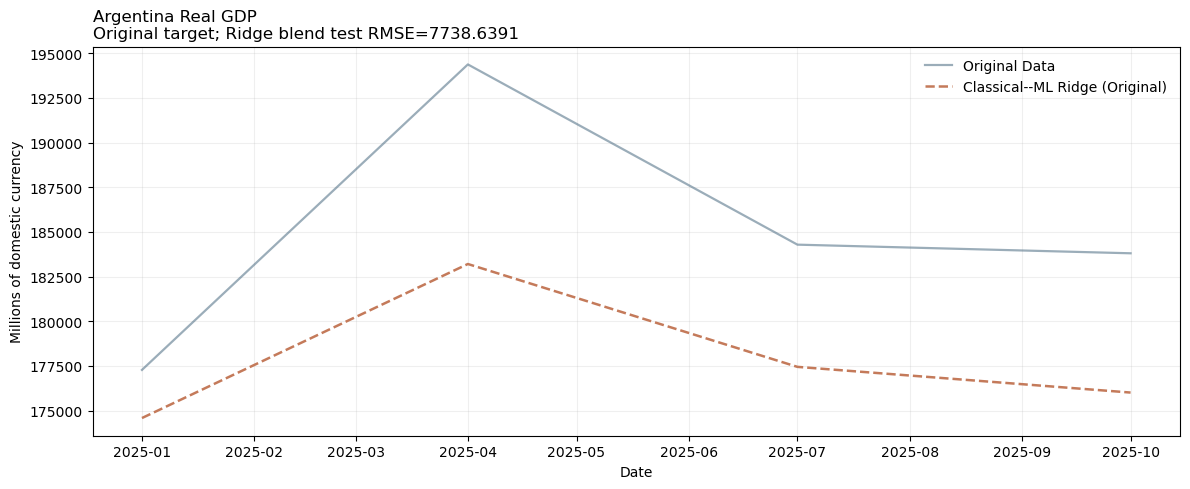

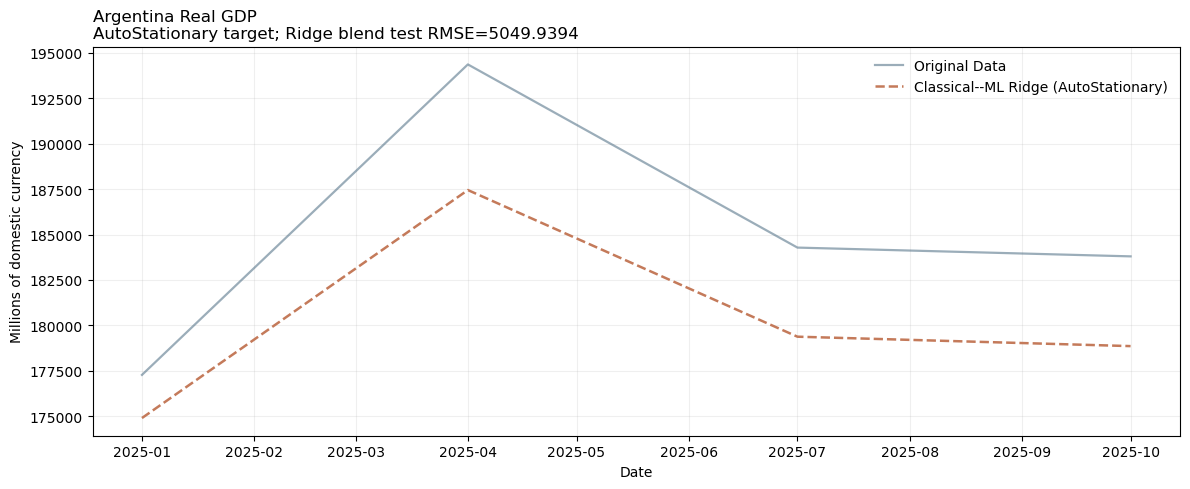


PLOTTING: real_gdp_us (manual)



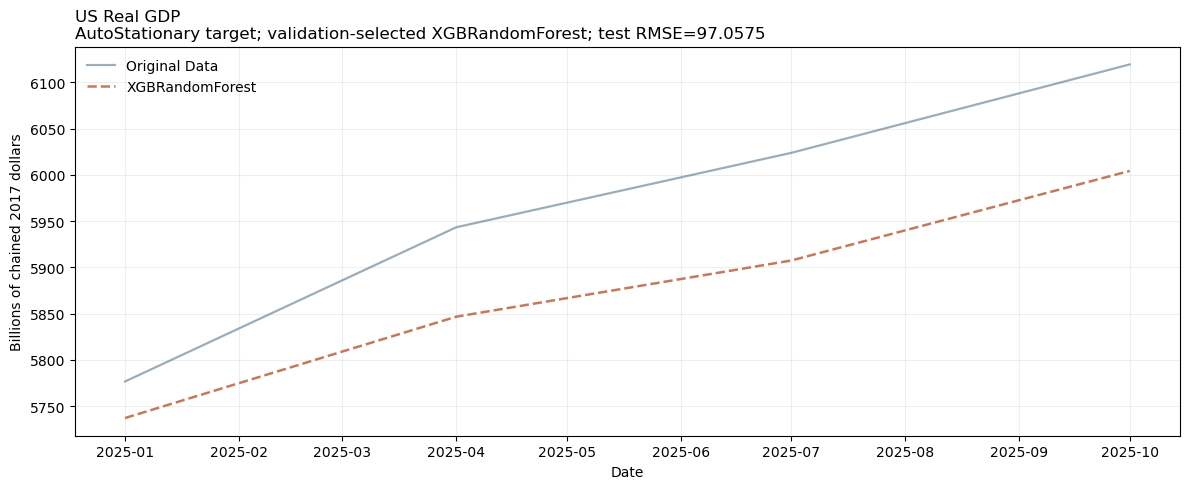

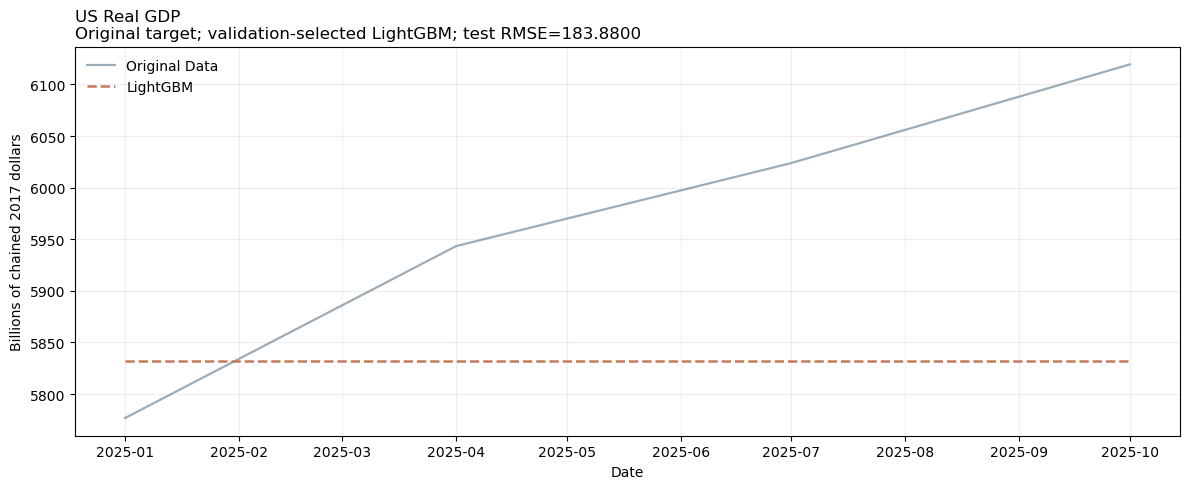

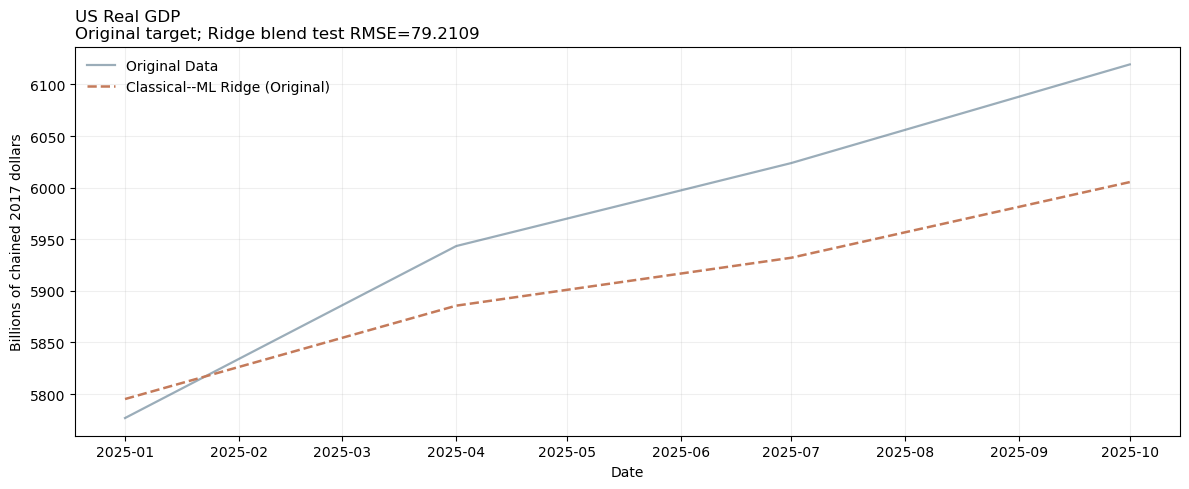

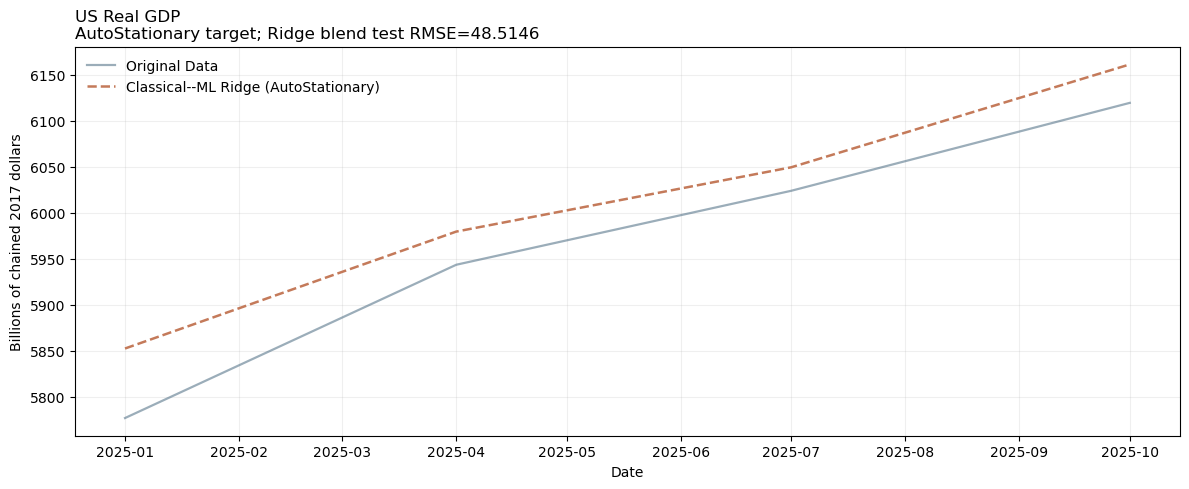


✓ Plotting complete



In [15]:
# ============================================================================
# PLOTTING: Show only each series/target version's validation-selected forecast
# ============================================================================

if EVALUATION_SPLIT == 'validation':
    plot_selection_metrics = {
        data['config'].get('selection_metric', 'rmse')
        for data in all_results.values()
    }
    if len(plot_selection_metrics) != 1:
        raise ValueError('Plot selection requires one common metric')
    plot_selection = summarize_model_selection(
        {name: data['metrics'] for name, data in all_results.items()},
        ml_configs_by_dataset,
        metric=plot_selection_metrics.pop(),
        series_col={name: data['id_col'] for name, data in all_results.items()},
        aggregate_replicates=False,
    )
else:
    plot_selection = frozen_selection

for dataset_name, data in all_results.items():
    dataset_type = data['type']
    metrics = data['metrics']
    results = data['results']
    time_col = data['time_col']
    target_col = data['target_col']

    print(f"\n{'='*80}")
    print(f"PLOTTING: {dataset_name} ({dataset_type})")
    print(f"{'='*80}\n")

    if plot_selection is not None:
        for series_name, target_winners in plot_selection['per_series'][dataset_name].items():
            plot_series_name = series_name
            plot_series_label = display_series_name(dataset_name, series_name)
            series_results = results[
                results[data['id_col']].astype(str).eq(str(plot_series_name))
            ]
            for target_version, winner in target_winners.items():
                model_name = winner['model']
                metric_row = metrics[
                    metrics[data['id_col']].astype(str).eq(str(plot_series_name))
                    & metrics['Target Transformation'].eq(target_version)
                    & metrics['Model'].eq(model_name)
                ].iloc[0]
                fig = plot_forecast_matplotlib(
                    series_results, [model_name], time_col, target_col,
                    forecast_display_names=[winner['base_model']],
                )
                apply_matplotlib_dataset_labels(
                    fig, dataset_name,
                    title_suffix=(
                        f'{target_version} target; '
                        f"validation-selected {winner['base_model']}; "
                        f"{EVALUATION_SPLIT} RMSE={metric_row['rmse']:.4f}"
                    ),
                )
                save_matplotlib_figure(
                    fig,
                    figure_path(
                        'ml_models', dataset_name, target_version,
                        EVALUATION_SPLIT, winner['base_model'],
                        extension=FIGURE_FORMAT,
                    ),
                    SAVE_FIGURES,
                )
                plt.show()
                plt.close(fig)
        if EVALUATION_SPLIT == 'test':
            for series_name in plot_selection['per_series'][dataset_name]:
                plot_series_name = series_name
                plot_series_label = display_series_name(dataset_name, series_name)
                series_results = results[
                    results[data['id_col']].astype(str).eq(str(plot_series_name))
                ]
                for target_version in ['Original', 'AutoStationary']:
                    output_name = blend_model_name(target_version)
                    blend_metric = metrics[
                        metrics[data['id_col']].astype(str).eq(str(plot_series_name))
                        & metrics['Model'].eq(output_name)
                    ].iloc[0]
                    fig = plot_forecast_matplotlib(
                        series_results,
                        [output_name],
                        time_col,
                        target_col,
                        forecast_display_names=[
                            f'Classical--ML Ridge ({target_version})'
                        ],
                    )
                    apply_matplotlib_dataset_labels(
                        fig, dataset_name,
                        title_suffix=(
                            f'{target_version} target; '
                            f"Ridge blend test RMSE={blend_metric['rmse']:.4f}"
                        ),
                    )
                    save_matplotlib_figure(
                        fig,
                        figure_path(
                            'ml_models', dataset_name, target_version,
                            'test', 'ridge_blend', extension=FIGURE_FORMAT,
                        ),
                        SAVE_FIGURES,
                    )
                    plt.show()
                    plt.close(fig)
        continue

print(f"\n{'='*80}")
print('✓ Plotting complete')
print(f"{'='*80}\n")

In [16]:
# ============================================================================
# GENERATE AND DISPLAY RESULTS TABLES
# ============================================================================

all_tables = {}
comparison_tables = {}

for dataset_name, data in all_results.items():
    all_tables[dataset_name] = {}
    for target_version in ['Original', 'AutoStationary']:
        version_metrics = data['metrics'].loc[
            data['metrics']['Target Transformation'] == target_version
        ]
        all_tables[dataset_name][target_version] = humanize_results_table(
            build_results_table(version_metrics, data['id_col'], data['type']),
            dataset_name,
        )
    reporting_metrics = data['metrics']
    comparison_tables[dataset_name] = prepare_comparison_metrics(
        reporting_metrics,
        dataset_name=dataset_name,
        dataset_type=data['type'],
        series_col=data['id_col'],
        model_family='Machine Learning',
        split=EVALUATION_SPLIT,
    )
    comparison_tables[dataset_name].loc[
        comparison_tables[dataset_name]['Model'].str.startswith(BLEND_MODEL_NAME),
        'Model Family',
    ] = 'Ensemble'

    for target_version, result_table in all_tables[dataset_name].items():
        print(f"\n{'='*100}")
        print(
            f"TABLE: {data['config']['label']} ({data['type']}) — "
            f"{target_version} target"
        )
        print(f"{'='*100}")
        display(style_results_table(result_table))
        print(f"\nDataset: {data['config']['label']}")
        print(
            f"Series: {data['metrics'][data['id_col']].nunique()} | "
            f"Models: {result_table['Model'].nunique()}"
        )


TABLE: EMAE (Argentina) (manual) — Original target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,RidgeBlend_ClassicalML,2.8956,12.8575,3.5857,-1.41,0.000954
1,LightGBM,5.4770,46.5954,6.8261,-3.53,0.223630
2,XGBRandomForest,5.7242,46.4187,6.8131,-3.40,0.089664



Dataset: EMAE (Argentina)
Series: 1 | Models: 3

TABLE: EMAE (Argentina) (manual) — AutoStationary target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,RidgeBlend_ClassicalML_AutoStationary,2.2071,6.5004,2.5496,-0.63,0.000817
1,XGBRandomForest_AutoStationary,2.5675,9.8014,3.1307,0.94,0.179424
2,LightGBM_AutoStationary,2.8508,11.3279,3.3657,0.67,0.093311



Dataset: EMAE (Argentina)
Series: 1 | Models: 3

TABLE: Coincident Economic Activity Index (United States) (manual) — Original target


...


Dataset: Real GDP (Argentina)
Series: 1 | Models: 3

TABLE: Real GDP (United States) (manual) — Original target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,RidgeBlend_ClassicalML,70.4901,6274.3654,79.2109,-1.03,0.001481
1,XGBRandomForest,123.6658,23398.2609,152.9649,-1.98,0.055342
2,LightGBM,161.6506,33811.8607,183.8800,-2.25,0.158495



Dataset: Real GDP (United States)
Series: 1 | Models: 3

TABLE: Real GDP (United States) (manual) — AutoStationary target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,RidgeBlend_ClassicalML_AutoStationary,44.7496,2353.6707,48.5146,0.75,0.001043
1,XGBRandomForest_AutoStationary,91.8927,9420.1519,97.0575,-1.54,0.064863
2,LightGBM_AutoStationary,105.7007,12165.1263,110.2956,-1.77,0.036216



Dataset: Real GDP (United States)
Series: 1 | Models: 3


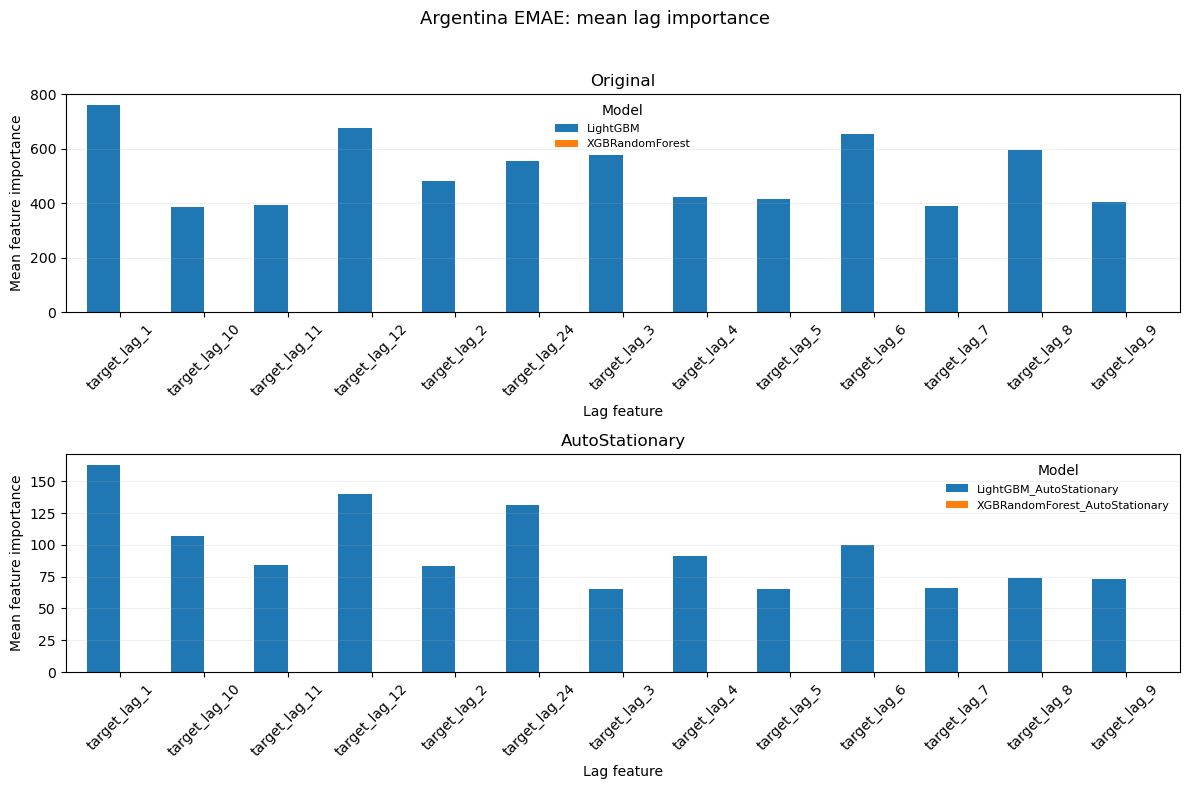

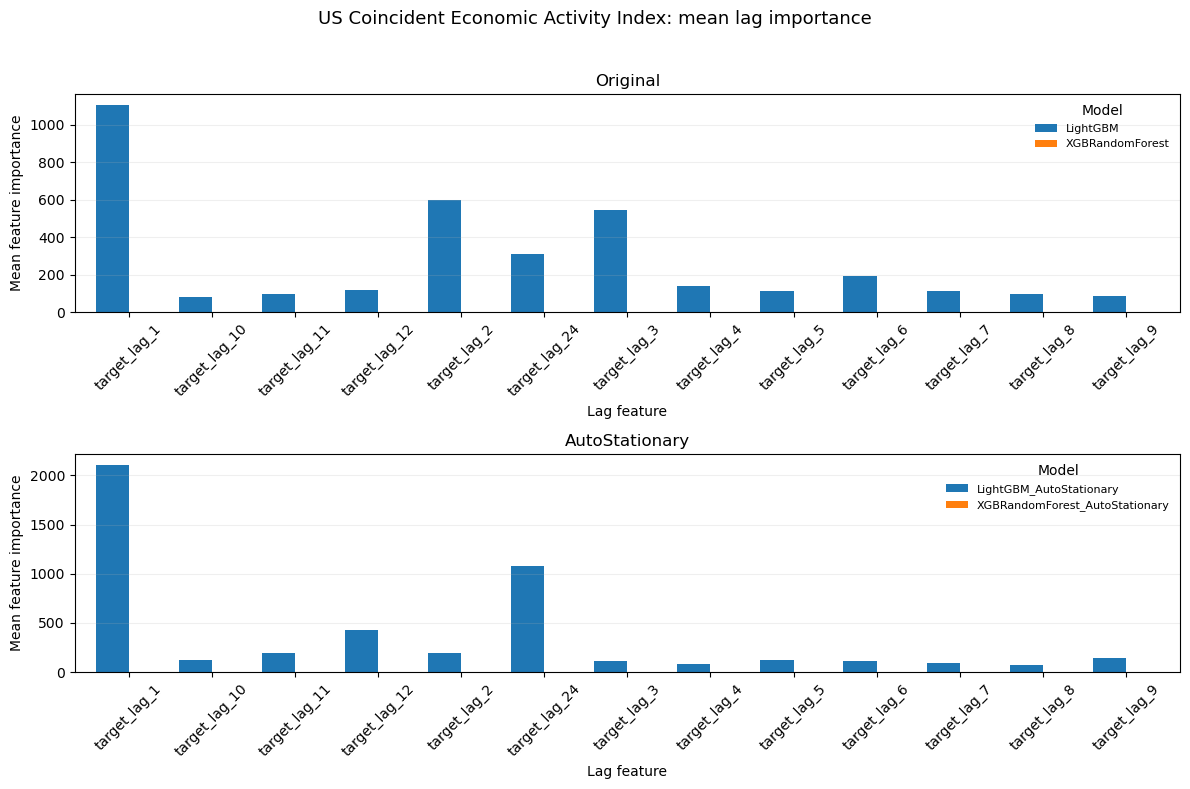

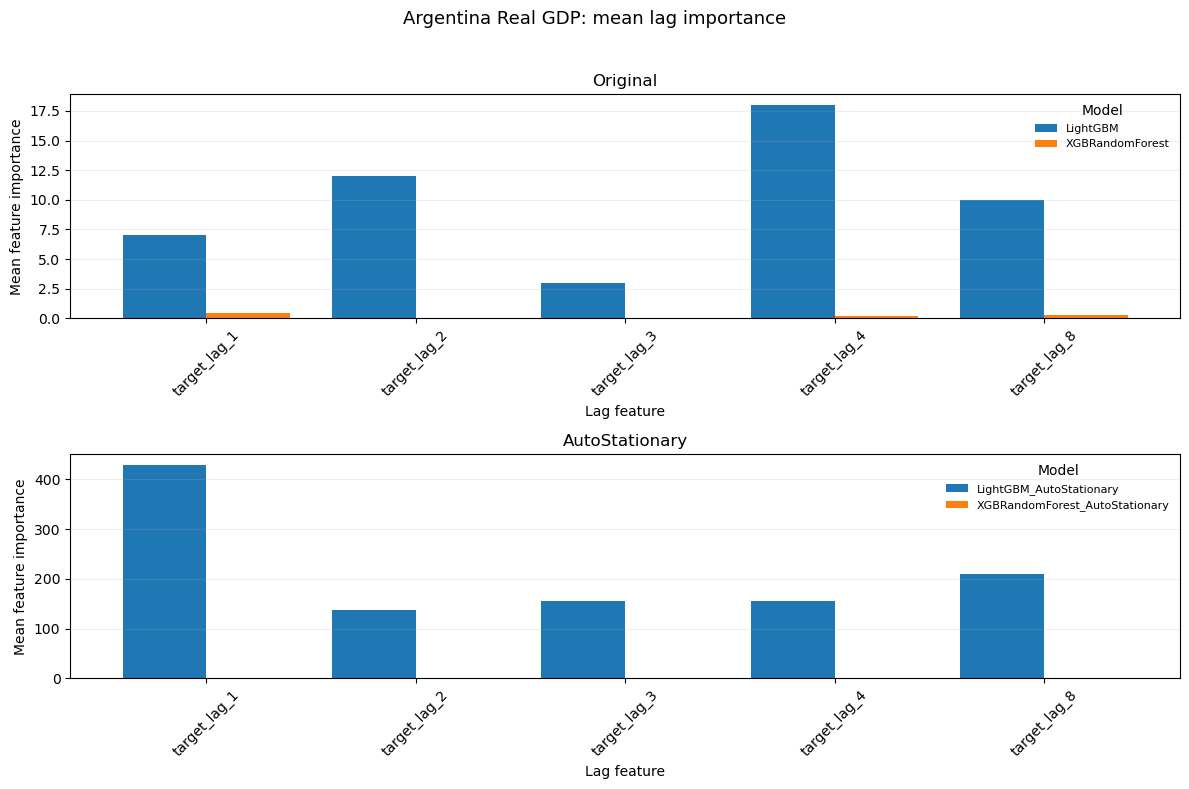

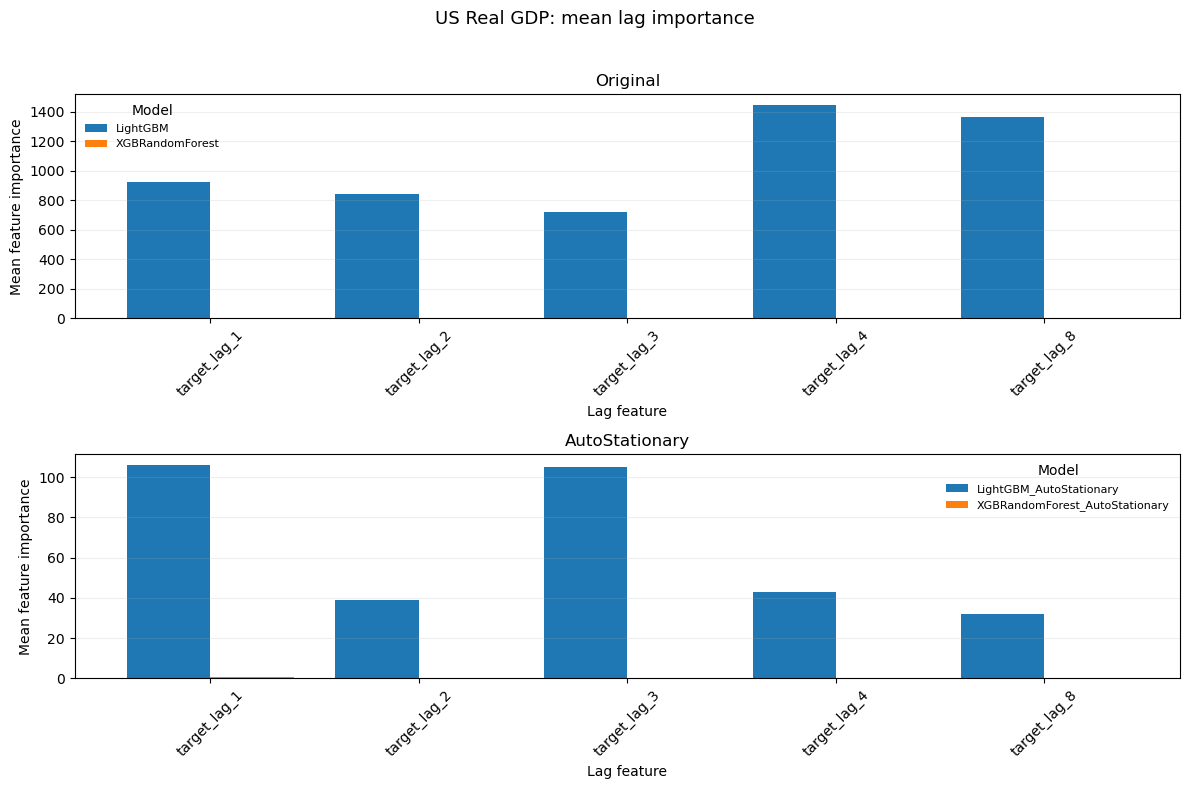

In [17]:
for dataset_name, data in all_results.items():
    importance = data['feature_importance']
    if importance.empty:
        continue
    average_importance = (
        importance.groupby(['Model', 'Target Transformation', 'Feature'], as_index=False)
        ['Importance'].mean()
        .sort_values(['Model', 'Target Transformation', 'Importance'], ascending=[True, True, False])
    )
    transformations = list(dict.fromkeys(average_importance['Target Transformation']))
    fig, axes = plt.subplots(
        len(transformations), 1,
        figsize=(12, max(4.5, 4.0 * len(transformations))),
        squeeze=False,
    )
    for axis, transformation in zip(axes[:, 0], transformations):
        subset = average_importance[
            average_importance['Target Transformation'].eq(transformation)
        ]
        wide = subset.pivot_table(
            index='Feature', columns='Model', values='Importance', aggfunc='mean'
        )
        wide.plot(kind='bar', ax=axis, width=0.80)
        axis.set(
            title=str(transformation), xlabel='Lag feature',
            ylabel='Mean feature importance',
        )
        axis.tick_params(axis='x', rotation=45)
        axis.grid(axis='y', alpha=0.20)
        axis.legend(title='Model', frameon=False, fontsize=8)
    fig.suptitle(
        f"{metadata_for(dataset_name)['display_name']}: mean lag importance",
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    save_matplotlib_figure(
        fig,
        figure_path(
            'ml_models', dataset_name, EVALUATION_SPLIT,
            'feature_importance', extension=FIGURE_FORMAT,
        ),
        SAVE_FIGURES,
    )
    plt.show()
    plt.close(fig)

## LaTeX table, persisted metrics, and classical comparison

The LaTeX table uses the same seven-column tabular format as `thesis/results/results_table_ml_<split>_emae.tex`. The CSV exports retain dataset, model-family, transformation, and split metadata so validation and final-test scores cannot be mixed later. CSV is the canonical metrics artifact; no redundant pickle is written.

Each split also exports a separate runtime table with preprocessing, Optuna tuning, final training, forecasting, and end-to-end time. Validation accuracy documents base-model selection; final test accuracy is the reported generalization result, while validation runtime documents selection cost. Test tables retain XGBRandomForest and LightGBM using their own frozen validation-tuned configurations; test performance is not used to change the locked validation winner.

Separate per-series Ridge blends are fitted for the Original and AutoStationary tracks. Validation forecasts are meta-training inputs, so neither blend has an honest validation score. Their frozen coefficients are evaluated for the first time on test and each result is inserted into its corresponding Original or AutoStationary table. Matching classical and ML forecast paths are also exported as CSV files; fitted Ridge coefficients and component provenance are stored in JSON, not pickle.


In [18]:
print(f"\n{'='*100}")
print('LaTeX EXPORT')
print(f"{'='*100}")

ml_comparison_tables = []
for dataset_name, version_tables in all_tables.items():
    print(f"\n{'-'*100}")
    print(f"Dataset: {dataset_name}")
    print(f"{'-'*100}")
    for target_version, result_table in version_tables.items():
        reporting = all_results[dataset_name]['config']['reporting']
        latex_table = publication_latex(
            result_table,
            caption=(
                f"{reporting['display_name']}; "
                f"{reporting['frequency']}; "
                f"{reporting['units']}; "
                f"{reporting['seasonal_adjustment']}. "
                f"Machine-learning {EVALUATION_SPLIT} results on the {target_version} target."
            ),
            label=f'tab:ml-{EVALUATION_SPLIT}-{dataset_name}-{target_version.lower()}',
            float_format=lambda value: (
                f'{value:.6f}' if abs(value) < 100 else f'{value:.2f}'
            ),
        )
        print(f'\nLaTeX TABLE CODE — {target_version}:')
        print(latex_table)
    latex_path = export_results_tables_latex(
        version_tables, dataset_name, method_name=f'ml_{EVALUATION_SPLIT}'
    )
    runtime_columns = [
        'Preprocessing Time', 'Tuning Time', 'Training Time',
        'Forecast Time', 'Time Elapsed', 'Best Iteration',
    ]
    available_runtime_columns = [
        column for column in runtime_columns
        if column in all_results[dataset_name]['metrics']
    ]
    runtime_table = (
        all_results[dataset_name]['metrics']
        .groupby(['Model', 'Target Transformation'], as_index=False, dropna=False)
        [available_runtime_columns]
        .mean()
    )
    runtime_path = export_results_table_latex(
        runtime_table, dataset_name,
        method_name=f'ml_{EVALUATION_SPLIT}_runtime',
    )

    comparison_table = comparison_tables[dataset_name]
    paths = export_comparison_metrics(
        comparison_table, f'ml_models_{EVALUATION_SPLIT}', dataset_name
    )
    ml_comparison_tables.append(comparison_table)
    print(f"✓ LaTeX table: {latex_path}")
    print(f"✓ Metrics CSV: {paths['csv']}")
    print(f'? Runtime LaTeX table: {runtime_path}')

if ml_comparison_tables and EXECUTION_MODE == 'batch':
    ml_metrics_all = pd.concat(ml_comparison_tables, ignore_index=True)
    export_comparison_metrics(
        ml_metrics_all, f'ml_models_{EVALUATION_SPLIT}', 'all'
    )
elif EXECUTION_MODE == 'single':
    print('Single mode leaves the complete batch metrics_all file unchanged.')

# End-of-run EMAE and batch-output verification.
emae_frame, emae_config = load_dataset('emae', 'manual')
_, emae_validation, emae_test, emae_id, emae_time, emae_target = (
    create_train_val_test_splits(emae_frame, emae_config, 'manual')
)
assert emae_validation.groupby(emae_id).size().eq(12).all()
assert emae_test.groupby(emae_id).size().eq(12).all()
assert pd.DatetimeIndex(
    pd.to_datetime(emae_test[emae_time]).drop_duplicates().sort_values()
).equals(pd.date_range('2025-01-01', '2025-12-01', freq='MS'))
if 'emae' in all_results:
    emae_run = all_results['emae']
    emae_predictions = emae_run['results'].copy()
    emae_predictions[emae_time] = pd.to_datetime(emae_predictions[emae_time])
    expected_dates = pd.date_range(
        '2024-01-01' if EVALUATION_SPLIT == 'validation' else '2025-01-01',
        periods=12, freq='MS',
    )
    assert pd.DatetimeIndex(
        emae_predictions[emae_time].drop_duplicates().sort_values()
    ).equals(expected_dates)
    compared_models = emae_run['metrics']['Model'].drop_duplicates().tolist()
    assert set(compared_models).issubset(emae_predictions.columns)
    for model_name in compared_models:
        model_dates = pd.DatetimeIndex(
            emae_predictions.loc[
                emae_predictions[model_name].notna(), emae_time
            ].drop_duplicates().sort_values()
        )
        assert model_dates.equals(expected_dates), model_name
    if EVALUATION_SPLIT == 'test':
        fit_dates = pd.to_datetime(emae_run['fit_df'][emae_time])
        assert fit_dates.max() < expected_dates.min()
        december = emae_predictions.loc[
            emae_predictions[emae_time].eq(pd.Timestamp('2025-12-01'))
        ]
        assert len(december) == 1
        assert december[compared_models].notna().all().all()
if EXECUTION_MODE == 'batch':
    expected_batch = set(POINT_FORECAST_DATASETS)
    assert set(all_results) == expected_batch
    assert set(all_tables) == expected_batch
    assert set(ml_metrics_all['Dataset']) == expected_batch
    saved_all = pd.read_csv(
        f'thesis/metrics/ml_models_{EVALUATION_SPLIT}_metrics_all.csv'
    )
    assert set(saved_all['Dataset']) == expected_batch
    for dataset_name in expected_batch:
        table_path = Path(
            f'thesis/results/results_table_ml_{EVALUATION_SPLIT}_{dataset_name}.tex'
        )
        assert table_path.is_file() and table_path.stat().st_size > 0
print('EMAE horizon and batch-consolidation checks passed.')


LaTeX EXPORT

----------------------------------------------------------------------------------------------------
Dataset: emae
----------------------------------------------------------------------------------------------------

LaTeX TABLE CODE — Original:
\begin{table}[htbp]
\caption{Argentina EMAE; Monthly; Index (2004=100); Original series (not seasonally adjusted). Machine-learning test results on the Original target.}
\label{tab:ml-test-emae-original}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrr}
\toprule
Model & MAE & MSE & RMSE & Forecast Bias & Time Elapsed \\
\midrule
RidgeBlend\_ClassicalML & \textcolor{metricgreen}{2.895595} & \textcolor{metricgreen}{12.857537} & \textcolor{metricgreen}{\textbf{3.585741}} & \textcolor{metricgreen}{-1.405963} & \textcolor{metricgreen}{\textbf{0.000954}} \\
LightGBM & 5.476997 & 46.595373 & 6.826080 & -3.528524 & 0.223630 \\
XGBRandomForest & 5.724238 & 46.418697 & 6.813127 & -3.404547 & 0.089664 \\
\bottomrule
\end{tabul

In [19]:
combined_comparisons = []
for dataset_name, ml_table in comparison_tables.items():
    classical_path = Path(
        f'thesis/metrics/classical_models_{EVALUATION_SPLIT}_metrics_{dataset_name}.csv'
    )
    if not classical_path.exists():
        print(f'Run the classical metrics export cell first: {classical_path}')
        continue
    classical_table = pd.read_csv(classical_path)
    required_schema = {'Dataset', 'Model Family', 'Target Transformation', 'Split'}
    if not required_schema.issubset(classical_table.columns):
        print(f'Re-run the updated classical export cell to normalize {classical_path}.')
        continue
    same_split = classical_table[classical_table['Split'] == EVALUATION_SPLIT]
    combined_comparisons.append(pd.concat([same_split, ml_table], ignore_index=True))

if combined_comparisons:
    all_model_comparison = pd.concat(combined_comparisons, ignore_index=True)
    display(all_model_comparison.sort_values(['Dataset', 'Series Name', 'RMSE']))

,Dataset,Dataset Type,Series Name,Model Family,Model,Target Transformation,Split,MAE,MSE,RMSE,Forecast Bias,Time Elapsed,Configuration Source,Preprocessing Time,Tuning Time,Training Time,Forecast Time,Best Iteration
8,ecai_us,manual,ECAI_US,Classical,AutoETS_AutoStationary,AutoStationary,test,0.171901,4.995089e-02,0.223497,-0.117202,0.098765,NaN,NaN,NaN,NaN,NaN,NaN
9,ecai_us,manual,ECAI_US,Classical,AutoTBATS,Original,test,0.206341,5.901410e-02,0.242928,-0.140683,2.516987,NaN,NaN,NaN,NaN,NaN,NaN
13,ecai_us,manual,ECAI_US,Machine Learning,XGBRandomForest_AutoStationary,AutoStationary,test,0.830668,6.993324e-01,0.836261,-0.566348,0.112450,NaN,NaN,0.0,0.091090,0.021361,NaN
15,ecai_us,manual,ECAI_US,Ensemble,RidgeBlend_ClassicalML,Original,test,1.168424,1.410761e+00,1.187755,0.796630,0.000976,Validation-trained Ridge blend of the best cla...,0.0,0.0,0.000849,0.000128,NaN
14,ecai_us,manual,ECAI_US,Ensemble,RidgeBlend_ClassicalML_AutoStationary,AutoStationary,test,1.525415,2.370421e+00,1.539617,1.040026,0.001060,Validation-trained Ridge blend of the best cla...,0.0,0.0,0.000924,0.000137,NaN
12,ecai_us,manual,ECAI_US,Machine Learning,LightGBM_AutoStationary,AutoStationary,test,1.802412,3.258012e+00,1.804996,-1.228882,0.156575,NaN,NaN,0.0,0.139139,0.017436,697.0
11,ecai_us,manual,ECAI_US,Machine Learning,XGBRandomForest,Original,test,2.926708,9.043510e+00,3.007243,-1.995426,0.133775,NaN,NaN,0.0,0.118731,0.015045,NaN
10,ecai_us,manual,ECAI_US,Machine Learning,LightGBM,Original,test,3.514042,1.282638e+01,3.581394,-2.395870,0.113481,NaN,NaN,0.0,0.102961,0.010520,202.0
1,emae,manual,EMAE,Classical,AutoARIMA,Original,test,1.945080,5.174976e+00,2.274857,0.156697,4.112842,NaN,NaN,NaN,NaN,NaN,NaN
6,emae,manual,EMAE,Ensemble,RidgeBlend_ClassicalML_AutoStationary,AutoStationary,test,2.207110,6.500386e+00,2.549585,-0.630904,0.000817,Validation-trained Ridge blend of the best cla...,0.0,0.0,0.000675,0.000143,NaN


In [20]:
# ============================================================================
# BEST MODEL ANALYSIS
# ============================================================================

print(f"\n{'='*100}")
print('BEST MODEL ANALYSIS')
print('Ridge is reported as an ensemble, but excluded from ML model selection.')
print(f"{'='*100}\n")

# Persist selections only from validation; test remains an unbiased report.
if EVALUATION_SPLIT == 'validation':
    selection_metrics = {
        data['config'].get('selection_metric', 'rmse')
        for data in all_results.values()
    }
    if len(selection_metrics) != 1:
        raise ValueError('Overall ranking requires one common selection metric')
    selection_metric = selection_metrics.pop()
    base_ml_metrics = {
        name: data['metrics'].loc[
            ~data['metrics']['Model'].astype(str).str.startswith(BLEND_MODEL_NAME)
        ].copy()
        for name, data in all_results.items()
    }
    new_ml_selection = summarize_model_selection(
        base_ml_metrics,
        ml_configs_by_dataset,
        metric=selection_metric,
        aggregate_replicates=False,
    )
    ml_selection = (
        merge_model_selections(load_model_selection(ML_SELECTION_PATH), new_ml_selection)
        if ML_SELECTION_PATH.exists() else new_ml_selection
    )
    selection_path = export_model_selection(
        ml_selection,
        ML_SELECTION_PATH,
    )
    candidate_store = (
        load_model_selection(ML_CANDIDATES_PATH)
        if ML_CANDIDATES_PATH.exists() else {
            'protocol': 'Manual-dataset validation candidates for explicit global transfer',
            'per_dataset': {},
        }
    )
    candidate_store.setdefault('per_dataset', {}).update(ml_configs_by_dataset)
    export_model_selection(candidate_store, ML_CANDIDATES_PATH)
    for dataset_name, target_winners in ml_selection['per_dataset'].items():
        for target_version, winner in target_winners.items():
            print(
                f"{dataset_name} [{target_version}]: {winner['model']} | "
                f"{selection_metric.upper()}={winner['validation_score']:.6f}"
            )
    for target_version, overall in ml_selection['overall_by_target'].items():
        print(
            f"\nCross-dataset candidate for a later global benchmark ({target_version}): "
            f"{overall['model']} | "
            f"mean rank={overall['mean_rank']:.3f}"
        )
    print(f"✓ Selection saved to: {selection_path}")
    print("This is the validation selection report. Set EVALUATION_SPLIT='test' and rerun from the top for the locked final-test report.")
else:
    selection_file = ML_SELECTION_PATH
    if not selection_file.exists():
        raise FileNotFoundError(
            f'No frozen validation selection found at {selection_file}; run validation first.'
        )
    frozen_selection = load_model_selection(selection_file)
    print('FINAL TEST SELECTION REPORT - validation-selected winners highlighted')
    print('The exported test tables retain every frozen ML candidate plus both Ridge blends.')
    print('Ridge remains excluded from the frozen candidates intended for comparison with DL.')
    for target_version, overall in frozen_selection['overall_by_target'].items():
        if str(overall['model']).startswith(BLEND_MODEL_NAME):
            raise ValueError('A Ridge ensemble cannot be a frozen base-ML candidate')
        print(
            f"Locked cross-dataset base-ML candidate ({target_version}): "
            f"{overall['model']} | validation mean rank={overall['mean_rank']:.3f}"
        )
    for dataset_name, data in all_results.items():
        selected_rows = []
        series_winners = frozen_selection['per_series'].get(dataset_name, {})
        for series_name, target_winners in series_winners.items():
            metric_series = data['metrics'][data['id_col']].astype(str)
            for target_version, winner in target_winners.items():
                mask = (
                    metric_series.eq(str(series_name))
                    & data['metrics']['Target Transformation'].eq(target_version)
                    & data['metrics']['Model'].eq(winner['model'])
                )
                winner_test = data['metrics'].loc[mask].copy()
                if winner_test.empty:
                    raise ValueError(
                        f"Missing test result for {dataset_name} / {series_name} / "
                        f"{target_version} / {winner['model']}"
                    )
                winner_test['Validation Score'] = winner['validation_score']
                winner_test['Selection Metric'] = winner['selection_metric'].upper()
                selected_rows.append(winner_test)
        if not selected_rows:
            raise ValueError(f'No per-series validation winners found for {dataset_name}')
        locked_test_metrics = pd.concat(selected_rows, ignore_index=True)
        report_columns = [
            data['id_col'], 'Target Transformation', 'Model',
            'Selection Metric', 'Validation Score',
            'mae', 'mse', 'rmse', 'forecast_bias', 'Time Elapsed',
        ]
        print(f'\n{dataset_name}: locked validation winners evaluated on test')
        display(
            locked_test_metrics[
                [column for column in report_columns if column in locked_test_metrics]
            ].sort_values([data['id_col'], 'Target Transformation'])
        )
        blend_rows = data['metrics'].loc[
            data['metrics']['Model'].str.startswith(BLEND_MODEL_NAME)
        ]
        if not blend_rows.empty:
            print(f'\n{dataset_name}: validation-trained Ridge blends on test')
            display(
                blend_rows[
                    [column for column in report_columns if column in blend_rows]
                ].sort_values(data['id_col'])
            )
    print('Validation selections were loaded read-only and were not overwritten.')


BEST MODEL ANALYSIS
Ridge is reported as an ensemble, but excluded from ML model selection.

FINAL TEST SELECTION REPORT - validation-selected winners highlighted
The exported test tables retain every frozen ML candidate plus both Ridge blends.
Ridge remains excluded from the frozen candidates intended for comparison with DL.
Locked cross-dataset base-ML candidate (AutoStationary): XGBRandomForest_AutoStationary | validation mean rank=1.250
Locked cross-dataset base-ML candidate (Original): LightGBM | validation mean rank=1.500

emae: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,EMAE,AutoStationary,XGBRandomForest_AutoStationary,RMSE,3.778782,2.567492,9.801445,3.130726,0.938049,0.179424
1,EMAE,Original,XGBRandomForest,RMSE,4.548335,5.724238,46.418697,6.813127,-3.404547,0.089664



emae: validation-trained Ridge blends on test


,unique_id,Target Transformation,Model,mae,mse,rmse,forecast_bias,Time Elapsed
4,EMAE,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,2.207110,6.500386,2.549585,-0.630904,0.000817
5,EMAE,Original,RidgeBlend_ClassicalML,2.895595,12.857537,3.585741,-1.405963,0.000954



ecai_us: locked validation winners evaluated on test


...


real_gdp_us: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,REAL_GDP_US,AutoStationary,XGBRandomForest_AutoStationary,RMSE,113.283343,91.892653,9420.151922,97.057467,-1.540319,0.064863
1,REAL_GDP_US,Original,LightGBM,RMSE,180.175733,161.650573,33811.860736,183.880017,-2.249576,0.158495



real_gdp_us: validation-trained Ridge blends on test


,unique_id,Target Transformation,Model,mae,mse,rmse,forecast_bias,Time Elapsed
4,REAL_GDP_US,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,44.749595,2353.670740,48.514645,0.75010,0.001043
5,REAL_GDP_US,Original,RidgeBlend_ClassicalML,70.490120,6274.365428,79.210892,-1.02731,0.001481


Validation selections were loaded read-only and were not overwritten.


## Saved best-model report

This report is generated entirely from persisted validation selections and test metrics. It does not fit, tune, or forecast any model. Ridge results remain available as ensemble diagnostics but are excluded from the base-ML candidates used in later comparisons with deep-learning models.

In [21]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

selection_paths = [Path('thesis/model_configs/ml_validation_selection.json')]
selection_paths = [path for path in selection_paths if path.exists()]
if not selection_paths:
    raise FileNotFoundError('No saved ML validation selection was found.')

selected_records = []
global_candidate_records = []
ridge_records = []

for selection_path in selection_paths:
    with selection_path.open(encoding='utf-8') as selection_file:
        saved_selection = json.load(selection_file)

    selection_scope = 'manual datasets'
    for target_version, candidate in saved_selection.get('overall_by_target', {}).items():
        candidate_model = str(candidate['model'])
        if candidate_model.startswith('RidgeBlend'):
            raise ValueError('Ridge cannot be selected as a base-ML global candidate.')
        global_candidate_records.append({
            'Scope': selection_scope,
            'Target Transformation': target_version,
            'Base-ML Candidate': candidate_model,
            'Validation Mean Rank': candidate['mean_rank'],
            'Datasets': candidate['datasets'],
        })

    for dataset_name, series_selections in saved_selection.get('per_series', {}).items():
        test_metrics_path = Path(
            f'thesis/metrics/ml_models_test_metrics_{dataset_name}.csv'
        )
        test_metrics = (
            pd.read_csv(test_metrics_path)
            if test_metrics_path.exists() else pd.DataFrame()
        )
        for series_name, target_selections in series_selections.items():
            for target_version, winner in target_selections.items():
                winner_model = str(winner['model'])
                if winner_model.startswith('RidgeBlend'):
                    raise ValueError('Ridge cannot be a validation-selected base-ML winner.')
                test_match = pd.DataFrame()
                if not test_metrics.empty:
                    test_match = test_metrics.loc[
                        test_metrics['Series Name'].astype(str).eq(str(series_name))
                        & test_metrics['Target Transformation'].eq(target_version)
                        & test_metrics['Model'].eq(winner_model)
                    ]
                selected_records.append({
                    'Scope': selection_scope,
                    'Dataset': dataset_name,
                    'Series Name': series_name,
                    'Target Transformation': target_version,
                    'Validation-selected Base-ML Model': winner_model,
                    'Validation RMSE': winner['validation_score'],
                    'Test RMSE': (
                        test_match['RMSE'].iloc[0] if not test_match.empty else float('nan')
                    ),
                })

        if not test_metrics.empty:
            ridge_rows = test_metrics.loc[
                test_metrics['Model'].astype(str).str.startswith('RidgeBlend')
            ]
            for _, ridge_row in ridge_rows.iterrows():
                ridge_records.append({
                    'Scope': selection_scope,
                    'Dataset': dataset_name,
                    'Series Name': ridge_row['Series Name'],
                    'Target Transformation': ridge_row['Target Transformation'],
                    'Ensemble': ridge_row['Model'],
                    'Test RMSE': ridge_row['RMSE'],
                })

best_ml_report = pd.DataFrame(selected_records).sort_values(
    ['Scope', 'Dataset', 'Series Name', 'Target Transformation']
).reset_index(drop=True)
global_ml_candidates = pd.DataFrame(global_candidate_records).sort_values(
    ['Scope', 'Target Transformation']
).reset_index(drop=True)

print('VALIDATION-SELECTED BASE-ML MODELS AND THEIR LOCKED TEST PERFORMANCE')
display(best_ml_report)
print('\nBASE-ML CANDIDATES FOR LATER GLOBAL/DL COMPARISON (RIDGE EXCLUDED)')
display(global_ml_candidates)

Path('thesis/metrics').mkdir(parents=True, exist_ok=True)
best_ml_report.to_csv('thesis/metrics/ml_best_model_analysis.csv', index=False)
global_ml_candidates.to_csv(
    'thesis/metrics/ml_global_base_model_candidates.csv', index=False
)

if ridge_records:
    ridge_test_report = pd.DataFrame(ridge_records).sort_values(
        ['Scope', 'Dataset', 'Series Name', 'Target Transformation']
    ).reset_index(drop=True)
    print('\nRIDGE ENSEMBLE TEST RESULTS (REPORTED, NOT ELIGIBLE FOR BASE-MODEL SELECTION)')
    display(ridge_test_report)
    ridge_test_report.to_csv(
        'thesis/metrics/ml_ridge_ensemble_test_report.csv', index=False
    )

VALIDATION-SELECTED BASE-ML MODELS AND THEIR LOCKED TEST PERFORMANCE


,Scope,Dataset,Series Name,Target Transformation,Validation-selected Base-ML Model,Validation RMSE,Test RMSE
0,manual datasets,ecai_us,ECAI_US,AutoStationary,XGBRandomForest_AutoStationary,1.214338,0.836261
1,manual datasets,ecai_us,ECAI_US,Original,LightGBM,2.887935,3.581394
2,manual datasets,emae,EMAE,AutoStationary,XGBRandomForest_AutoStationary,3.778782,3.130726
3,manual datasets,emae,EMAE,Original,XGBRandomForest,4.548335,6.813127
4,manual datasets,real_gdp_argentina,REAL_GDP_ARGENTINA,AutoStationary,LightGBM_AutoStationary,4232.378542,4116.916789
5,manual datasets,real_gdp_argentina,REAL_GDP_ARGENTINA,Original,XGBRandomForest,6457.900365,9100.871825
6,manual datasets,real_gdp_us,REAL_GDP_US,AutoStationary,XGBRandomForest_AutoStationary,113.283343,97.057467
7,manual datasets,real_gdp_us,REAL_GDP_US,Original,LightGBM,180.175733,183.880017



BASE-ML CANDIDATES FOR LATER GLOBAL/DL COMPARISON (RIDGE EXCLUDED)


,Scope,Target Transformation,Base-ML Candidate,Validation Mean Rank,Datasets
0,manual datasets,AutoStationary,XGBRandomForest_AutoStationary,1.25,4
1,manual datasets,Original,LightGBM,1.50,4



RIDGE ENSEMBLE TEST RESULTS (REPORTED, NOT ELIGIBLE FOR BASE-MODEL SELECTION)


,Scope,Dataset,Series Name,Target Transformation,Ensemble,Test RMSE
0,manual datasets,ecai_us,ECAI_US,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,1.539617
1,manual datasets,ecai_us,ECAI_US,Original,RidgeBlend_ClassicalML,1.187755
2,manual datasets,emae,EMAE,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,2.549585
3,manual datasets,emae,EMAE,Original,RidgeBlend_ClassicalML,3.585741
4,manual datasets,real_gdp_argentina,REAL_GDP_ARGENTINA,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,5049.939369
5,manual datasets,real_gdp_argentina,REAL_GDP_ARGENTINA,Original,RidgeBlend_ClassicalML,7738.639140
6,manual datasets,real_gdp_us,REAL_GDP_US,AutoStationary,RidgeBlend_ClassicalML_AutoStationary,48.514645
7,manual datasets,real_gdp_us,REAL_GDP_US,Original,RidgeBlend_ClassicalML,79.210892
